# **Simple Moving Average Strategy**

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [73]:
company="HAL.NS"
start_date="2024-01-01"
end_date="2026-01-06"
data=yf.download(company,start_date,end_date)
df=pd.DataFrame(data["Close"])
df

/tmp/ipython-input-751521533.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data=yf.download(company,start_date,end_date)
[*********************100%***********************]  1 of 1 completed


Ticker,HAL.NS
Date,
2024-01-01,2768.619873
2024-01-02,2734.775391
2024-01-03,2811.378174
2024-01-04,2844.928467
2024-01-05,2937.596436
...,...
2025-12-30,4325.500000
2025-12-31,4388.700195
2026-01-01,4397.899902


1. Simple moving average have to multiple conditional statements starting from 1 min window to 100 days window.
2. Number of starting points will be vanished out according to the window set. Such as if we set windows=20 then, 20 day's data will be vanished out from starting.
3. use `df["Close"].rolling(window=7).mean()` for short windows and  `df["Close"].rolling(window=100).mean()`for long term windows.

In [74]:
short_terms=7
long_terms=20
df["SMA_S"]=df.iloc[:,0].rolling(window=short_terms).mean()
# df["SMA_M"]=df.iloc[:,0].rolling(window=15).mean()
df["SMA_L"]=df.iloc[:,0].rolling(window=long_terms).mean()
df

Ticker,HAL.NS,SMA_S,SMA_L
Date,,,
2024-01-01,2768.619873,NaN,NaN
2024-01-02,2734.775391,NaN,NaN
2024-01-03,2811.378174,NaN,NaN
2024-01-04,2844.928467,NaN,NaN
2024-01-05,2937.596436,NaN,NaN
...,...,...,...
2025-12-30,4325.500000,4392.157087,4350.244946
2025-12-31,4388.700195,4392.528530,4347.864966
2026-01-01,4397.899902,4391.171387,4342.919971


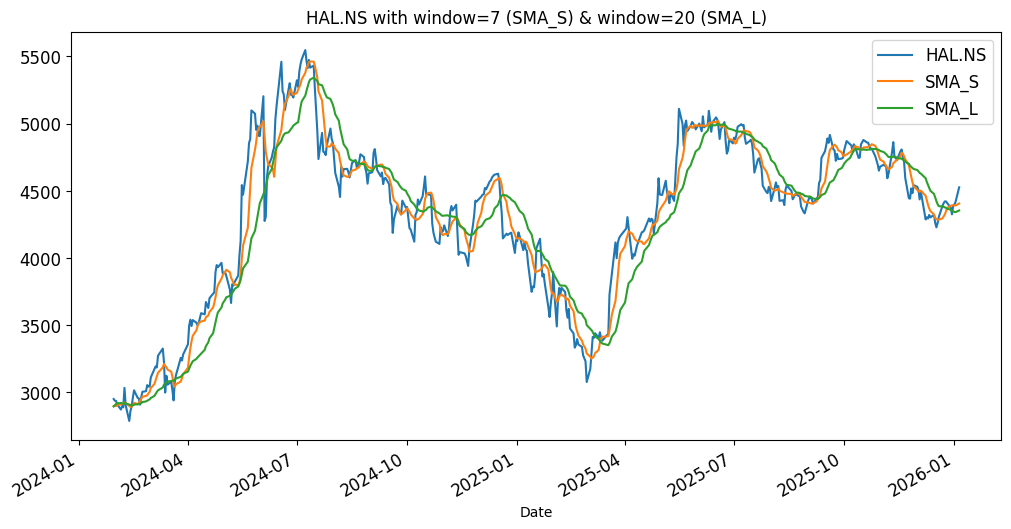

In [75]:
df.dropna().plot(figsize=(12,6),title=f"{company} with window={short_terms} (SMA_S) & window={long_terms} (SMA_L)",fontsize=12)
plt.legend(fontsize=12)
plt.show()

**Generating Trading signal:**
1. If `SMA_S > SMA_L` then its buy regime
2. If `SMA_S < SMA_L` then its sell regime

<Axes: title={'center': 'Trading signal based on SMA for HAL.NS'}, xlabel='Date'>

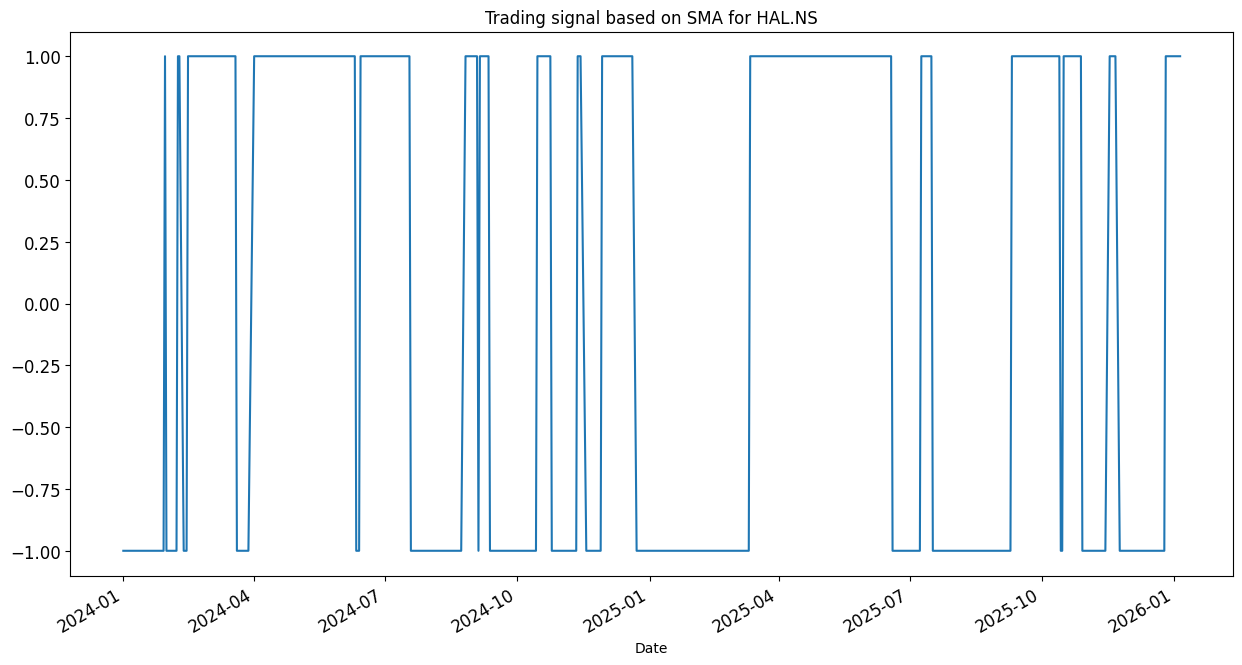

In [76]:
df["Signal"]=np.where(df['SMA_S']>df["SMA_L"],1,-1)
df['Signal'].plot(figsize=(15,8),fontsize=12,title=f"Trading signal based on SMA for {company}")

In [77]:
df

Ticker,HAL.NS,SMA_S,SMA_L,Signal
Date,,,,
2024-01-01,2768.619873,NaN,NaN,-1
2024-01-02,2734.775391,NaN,NaN,-1
2024-01-03,2811.378174,NaN,NaN,-1
2024-01-04,2844.928467,NaN,NaN,-1
2024-01-05,2937.596436,NaN,NaN,-1
...,...,...,...,...
2025-12-30,4325.500000,4392.157087,4350.244946,1
2025-12-31,4388.700195,4392.528530,4347.864966,1
2026-01-01,4397.899902,4391.171387,4342.919971,1


[251, 252]